# MFLike-JAX

_Author: Hidde T. Jense_

In this notebook I show how to:

- Instantiate the likelihood,
- Compute and plot a foreground model,
- Evaluate the likelihood at a fiducial cosmology/foreground.

Before you start, make sure you have installed both [LAT_MFLike](https://github.com/simonsobs/LAT_MFLike/) and [ACT DR6 MFLike](https://github.com/ACTCollaboration/act_dr6_mflike) and that you have installed the data for the latter. Whilst we won't be using LAT_MFLike in these tutorials, the JAX likelihood loads in the data from the ACT DR6 likelihood, so we will need it!

It will also be helpful if you are familiar with the [ACT DR6 Likelihood](https://github.com/ACTCollaboration/DR6_Notebooks/blob/main/ACT_DR6_ps_likelihood.ipynb), linked here.

In [1]:
import jax
import random
from jax import numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../")

import mflike_jax

import pprint

/home/ojima/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# We can instantiate the likelihood by loading a YAML file.
# These yaml files are 90% the same ones as are used in the non-jax likelihood.
like = mflike_jax.MFLike_jax("../act_dr6.yaml")

# The likelihood requires CMB C_ells as well as foreground bandpowers.
# We can create a foreground model with a similar class:
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

Assuming data rows are in the correct order as it was before version 1.0.


In [3]:
# For now, we will ignore the CMB part of the sampling as it would require some
# extra setup/modifications for something like cosmopower - we will only focus
# on the foregrounds for now!

# Create some standard CMB C_ells from camb
import camb

cosmo_params = {
    "ombh2": random.gauss(2.259e-2, 0.017e-2),
    "omch2": random.gauss(12.38e-2, 0.21e-2),
    "cosmomc_theta": random.gauss(104.056e-4, 0.031e-4),
    "ns": random.gauss(96.66e-2, 0.77e-2),
    "logA": random.gauss(3.053, 0.013),
    "tau": random.gauss(5.62e-2, 0.6e-2)
}

cosmo_params["As"] = 1e-10 * np.exp(cosmo_params.pop("logA"))

pars = camb.set_params(lens_potential_accuracy=8, lmax=8500, **cosmo_params)
res = camb.get_results(pars)
spec = res.get_cmb_power_spectra(CMB_unit="muK")["total"]

In [4]:
# We can take a look at which parameters the likelihood needs:
pprint.pprint(like.parameters)

['calG_all',
 'cal_dr6_pa4_f220',
 'calE_dr6_pa4_f220',
 'cal_dr6_pa5_f090',
 'calE_dr6_pa5_f090',
 'cal_dr6_pa5_f150',
 'calE_dr6_pa5_f150',
 'cal_dr6_pa6_f090',
 'calE_dr6_pa6_f090',
 'cal_dr6_pa6_f150',
 'calE_dr6_pa6_f150']


In [5]:
# And the foreground model:
pprint.pprint(fg_model.parameters)

['bandint_shift_dr6_pa4_f220',
 'bandint_shift_dr6_pa5_f090',
 'bandint_shift_dr6_pa5_f150',
 'bandint_shift_dr6_pa6_f090',
 'bandint_shift_dr6_pa6_f150',
 'a_kSZ',
 'a_tSZ',
 'alpha_tSZ',
 'a_c',
 'alpha_c',
 'xi',
 'beta_cib',
 'T_d',
 'a_p',
 'alpha_p',
 'a_s',
 'alpha_s',
 'beta_s',
 'a_gtt',
 'alpha_dT',
 'beta_d',
 'T_effd',
 'a_pste',
 'a_gte',
 'alpha_dE',
 'a_psee',
 'a_gee']


In [6]:
# You may recognize that these parameters are the same ones that are used in the DR6 multifrequency likelihood!
# (the only difference is that I have renamed beta_c = beta_p = beta_cib instead).
# Let's evaluate our likelihood at a fiducial set of parameters.

# Compare these numbers with the values reported and plotted in Louis et al (2025).
parameter_values = {
    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.09,
    "a_s": 2.9,
    "beta_s": -2.8,
    "a_pste": -0.026,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_c": 0.8,
    "alpha_p": 1.0,
    "alpha_s": 1.0,
    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

In [7]:
# The likelihood and foreground code do not take in a dictionary of values however, as JAX is designed to work with _arrays_ of numbers.
# Luckily, we know exactly in which order these arrays are expected to be given.
theta_like = jnp.array([ parameter_values[p] for p in like.parameters ])
theta_fg = jnp.array([ parameter_values[p] for p in fg_model.parameters ])

pprint.pprint(list(zip(fg_model.parameters, theta_fg)))

[('bandint_shift_dr6_pa4_f220', Array(0., dtype=float32)),
 ('bandint_shift_dr6_pa5_f090', Array(0., dtype=float32)),
 ('bandint_shift_dr6_pa5_f150', Array(0., dtype=float32)),
 ('bandint_shift_dr6_pa6_f090', Array(0., dtype=float32)),
 ('bandint_shift_dr6_pa6_f150', Array(0., dtype=float32)),
 ('a_kSZ', Array(1.5, dtype=float32)),
 ('a_tSZ', Array(3.4, dtype=float32)),
 ('alpha_tSZ', Array(-0.5, dtype=float32)),
 ('a_c', Array(3.7, dtype=float32)),
 ('alpha_c', Array(0.8, dtype=float32)),
 ('xi', Array(0.09, dtype=float32)),
 ('beta_cib', Array(1.9, dtype=float32)),
 ('T_d', Array(9.7, dtype=float32)),
 ('a_p', Array(7.7, dtype=float32)),
 ('alpha_p', Array(1., dtype=float32)),
 ('a_s', Array(2.9, dtype=float32)),
 ('alpha_s', Array(1., dtype=float32)),
 ('beta_s', Array(-2.8, dtype=float32)),
 ('a_gtt', Array(7.95, dtype=float32)),
 ('alpha_dT', Array(-0.6, dtype=float32)),
 ('beta_d', Array(1.5, dtype=float32)),
 ('T_effd', Array(19.6, dtype=float32)),
 ('a_pste', Array(-0.026, dtyp

In [8]:
# We can use these values to compute the foreground model.
foregrounds = fg_model.get_foreground_model(theta_fg)
# The resulting array will have a shape (xy, ell, exp1, exp2):
# - the first axis denotes the [TT, TE, EE] spectra
# - the second axis denotes the ell values
# - the third and fourth axes denote the two experiments of the cross-spectrum.
print(foregrounds.shape)
print(fg_model.experiments)

(3, 8499, 5, 5)
['dr6_pa4_f220', 'dr6_pa5_f090', 'dr6_pa5_f150', 'dr6_pa6_f090', 'dr6_pa6_f150']


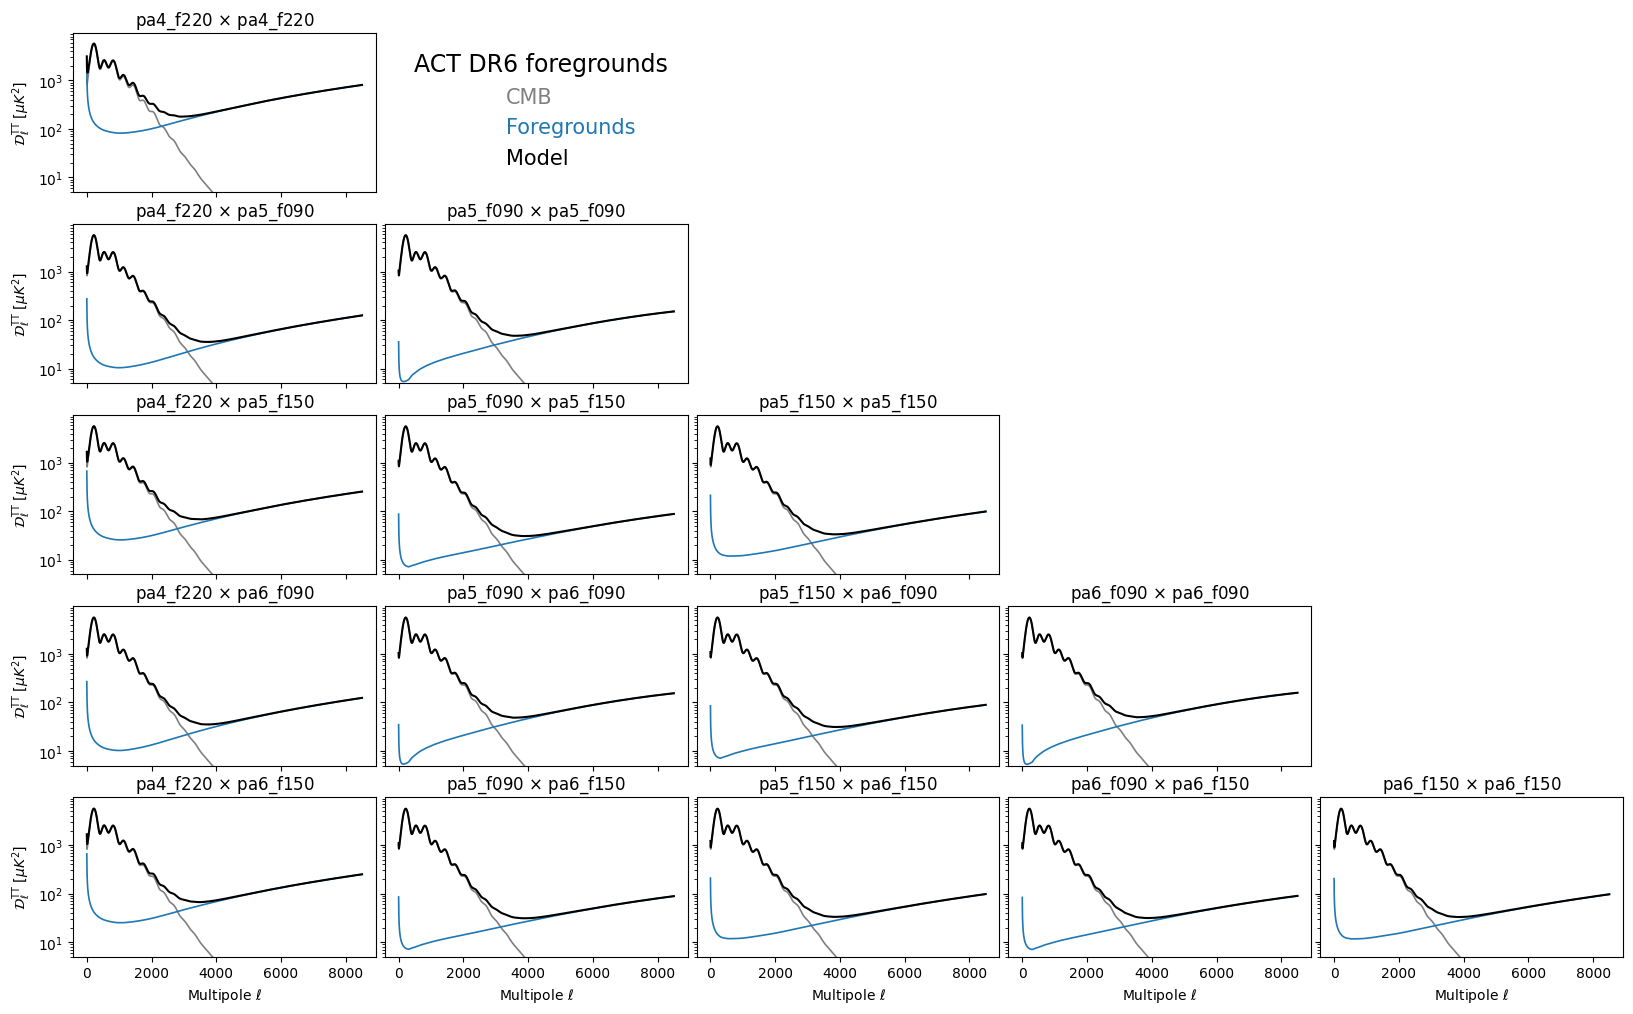

In [9]:
# We can plot some TT cross spectra here:

fig, axes = plt.subplots(len(fg_model.experiments), len(fg_model.experiments), figsize=(20, 12), sharex=True, sharey=True, gridspec_kw={"wspace": 0.03})

for i, exp1 in enumerate(fg_model.experiments):
    for j, exp2 in enumerate(fg_model.experiments):
        ax = axes[i,j]

        if j > i:
            fig.delaxes(ax)
            continue

        ax.set_title(f"{fg_model.experiments[j][4:]} $\\times$ {fg_model.experiments[i][4:]}")

        ax.plot(fg_model.ells, spec[fg_model.ells,0], c="grey", lw=1.2, label="CMB")
        ax.plot(fg_model.ells, foregrounds[0,:,i,j], c="C0", lw=1.2, label="Foregrounds")

        ax.plot(fg_model.ells, spec[fg_model.ells,0] + foregrounds[0,:,i,j], c="k", lw=1.5, label="Model")

        ax.semilogy()
        ax.set_ylim(5e0, None)

        if j == 0:
            ax.set_ylabel(r"$\mathcal{D}_\ell^{\rm TT}$ [$\mu K^2$]")
        if i == len(fg_model.experiments)-1:
            ax.set_xlabel(r"Multipole $\ell$")

L = axes[0,0].legend(title="ACT DR6 foregrounds", loc=(1.1, 0.1), fontsize=15, title_fontsize=17)
for t, h in zip(L.get_texts(), L.legend_handles):
	c = h.get_color()
	h.set_visible(False)
	t.set_color(c)
L.get_frame().set_edgecolor("none")

In [10]:
# The likelihood has a chi^2 function.
# It takes in C_ell TT, TE, EE, the foreground model we computed earlier, and the likelihood parameters.
chi2 = like.chisquare(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

print(f"chi^2 = {chi2:.2f} / {len(like.data_vec)} datapoints.")

chi^2 = 2355.42 / 1651 datapoints.


In [11]:
# Similar to LAT MFLike, we can also access the metadata of the likelihood directly, and plot the fit to the data.
m = like.spec_meta[0]

print(f"Data type: {m['dt']}")
print(f"Spectrum: {m['exp1']} x {m['exp2']}")
print(f"Data range: ell = {m['lmin']} - {m['lmax']}")
print(f"l_eff = {m['leff']}")
print(f"Indices = {m['ids']}")

Data type: cl_00
Spectrum: dr6_pa4_f220 x dr6_pa4_f220
Data range: ell = 1000 - 8500
l_eff = [1000.5 1050.5 1100.5 1150.5 1200.5 1250.5 1300.5 1350.5 1400.5 1450.5
 1500.5 1550.5 1600.5 1650.5 1700.5 1750.5 1800.5 1850.5 1900.5 1950.5
 2000.5 2075.5 2175.5 2275.5 2375.5 2475.5 2625.5 2825.5 3025.5 3325.5
 3725.5 4125.5 4525.5 4925.5 5325.5 5725.5 6125.5 6725.5 7525.5]
Indices = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]


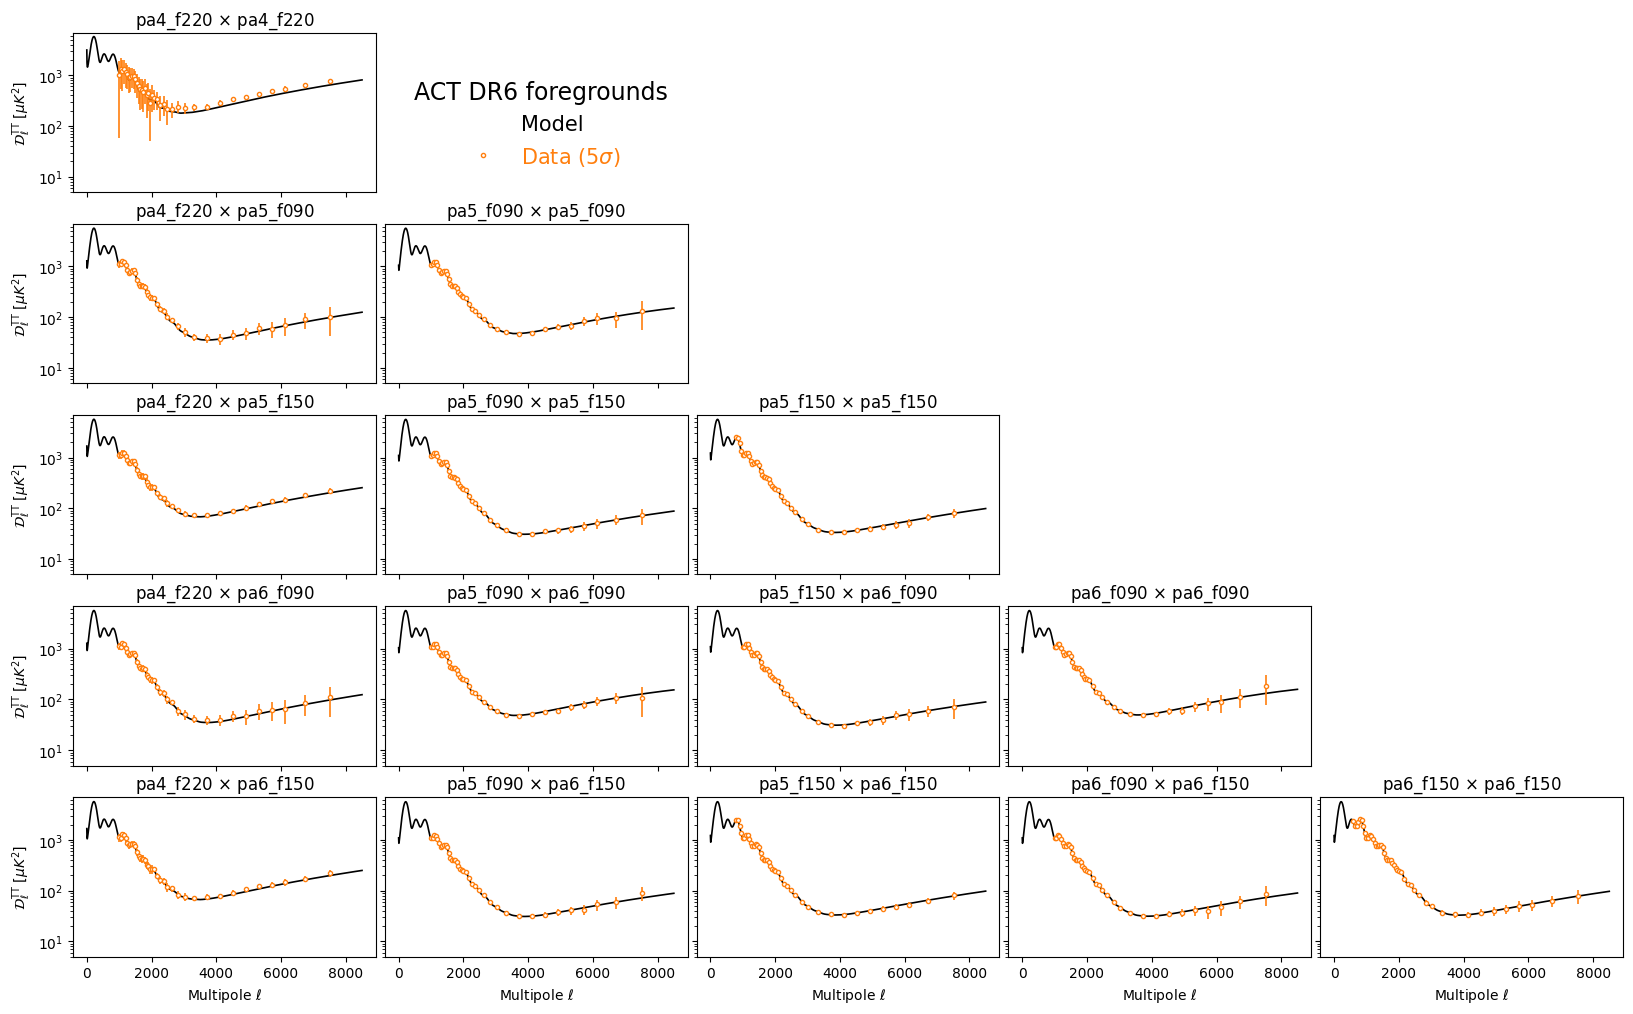

In [12]:
smooth_model = like.get_unbinned_model(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

fig, axes = plt.subplots(len(fg_model.experiments), len(fg_model.experiments), figsize=(20, 12), sharex=True, sharey=True, gridspec_kw={"wspace": 0.03})

for i, exp1 in enumerate(fg_model.experiments):
    for j, exp2 in enumerate(fg_model.experiments):
        ax = axes[i,j]

        if j > i:
            fig.delaxes(ax)
            continue

        ax.set_title(f"{fg_model.experiments[j][4:]} $\\times$ {fg_model.experiments[i][4:]}")

        ax.plot(fg_model.ells, smooth_model[0,:,i,j], c="k", lw=1.2, label="Model")

        ax.semilogy()
        ax.set_ylim(5e0, None)

        if j == 0:
            ax.set_ylabel(r"$\mathcal{D}_\ell^{\rm TT}$ [$\mu K^2$]")
        if i == len(fg_model.experiments)-1:
            ax.set_xlabel(r"Multipole $\ell$")

for m in like.spec_meta:
    if m["dt"] == "cl_00":
        i,j = m["ix"]
        ax = axes[j,i]
        ids = m["ids"]
        leff = m["leff"]
        cl = like.data_vec[ids]
        err = np.sqrt(np.diag(like.covmat)[ids])

        ax.errorbar(leff, cl, yerr=5. * err, lw=0, elinewidth=1.2, marker=".", markerfacecolor="white", markeredgecolor="C1", color="C1", label=r"Data ($5 \sigma$)")

L = axes[0,0].legend(title="ACT DR6 foregrounds", loc=(1.1, 0.1), fontsize=15, title_fontsize=17)
for t, h in zip(L.get_texts(), L.legend_handles):
	c = h.get_color()
	h.set_visible(False)
	t.set_color(c)
L.get_frame().set_edgecolor("none")

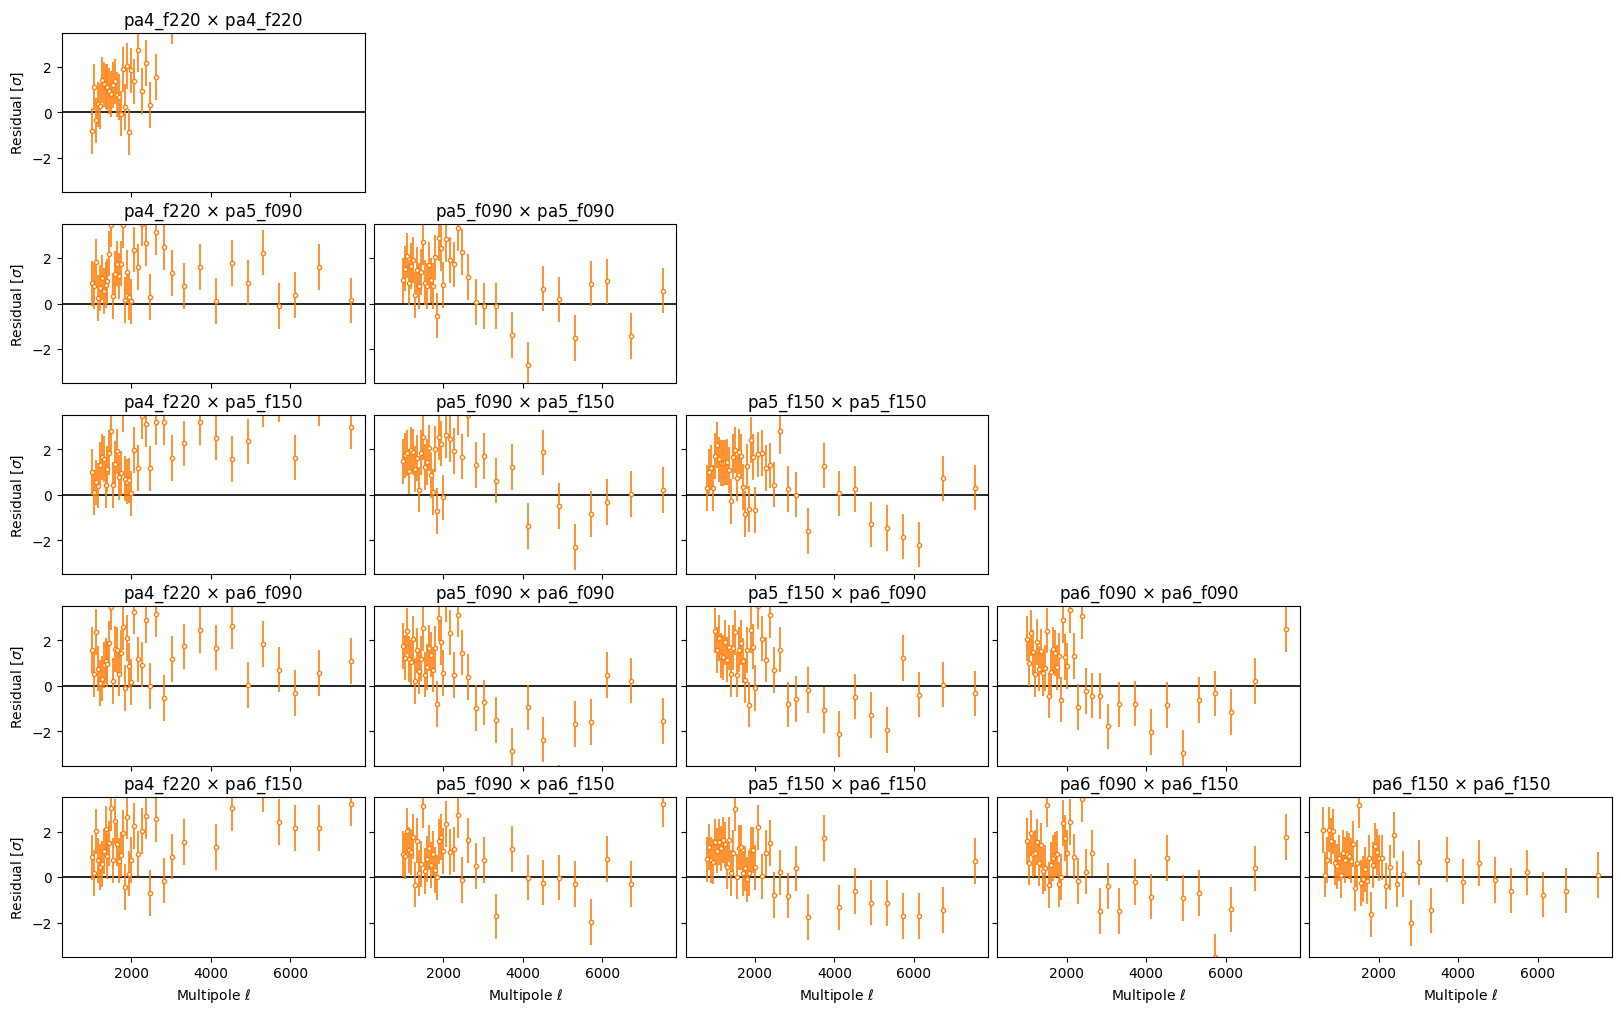

In [13]:
# We can plot residuals by directly accessing the model function of the likelihood:
model_vec = like.get_model(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

fig, axes = plt.subplots(len(fg_model.experiments), len(fg_model.experiments), figsize=(20, 12), sharex=True, sharey=True, gridspec_kw={"wspace": 0.03})

for i, exp1 in enumerate(fg_model.experiments):
    for j, exp2 in enumerate(fg_model.experiments):
        ax = axes[i,j]

        if j > i:
            fig.delaxes(ax)
            continue

        ax.set_title(f"{fg_model.experiments[j][4:]} $\\times$ {fg_model.experiments[i][4:]}")

        ax.axhline(0.0, c="k", lw=1.2)

        ax.set_ylim(-3.5, 3.5)

        if j == 0:
            ax.set_ylabel(r"Residual [$\sigma$]")
        if i == len(fg_model.experiments)-1:
            ax.set_xlabel(r"Multipole $\ell$")

for m in like.spec_meta:
    if m["dt"] == "cl_00":
        i,j = m["ix"]
        ax = axes[j,i]
        ids = m["ids"]
        leff = m["leff"]
        cl = like.data_vec[ids]
        cl_th = model_vec[ids]
        err = np.sqrt(np.diag(like.covmat)[ids])

        ax.errorbar(leff, (cl - cl_th) / err, yerr=np.ones_like(err), lw=0, elinewidth=1.2, marker=".", markerfacecolor="white", markeredgecolor="C1", color="C1")

In [17]:
# We can compare the likelihood with the official ACT DR6 MFLike and show they are equivalent.
from cobaya.model import get_model

act_params = cosmo_params | parameter_values
# Fix some parameters that have different names in MFLike.
act_params.pop("alpha_c")
act_params["beta_c"] = act_params.pop("beta_cib")
act_params["beta_p"] = act_params["beta_c"]

info = {
    "likelihood": { "act_dr6_mflike": None },
    "theory": {
        "camb": None,
        "mflike.BandpowerForeground": {
            "top_hat_band": None,
            "beam_profile": {"beam_from_file": None},
            "normalisation": {
                "nu_0": 150.0,
                "ell_0": 3000,
                "T_CMB": 2.725,
            },
            "experiments": [
                "dr6_pa4_f220",
                "dr6_pa5_f090",
                "dr6_pa5_f150",
                "dr6_pa6_f090",
                "dr6_pa6_f150",
            ],
            "bandint_freqs": [220, 90, 150, 90, 150],
            "components": {
                "tt": ["kSZ", "tSZ_and_CIB", "cibp", "dust", "radio"],
                "te": ["radio", "dust"],
                "ee": ["radio", "dust"],
            }
        }
    },
    "params": act_params
}

model = get_model(info)
model.logposterior({});

[camb] `camb` module loaded successfully from /home/ojima/Cardiff/camb/camb
Assuming data rows are in the correct order as it was before version 1.0.
[act_dr6_mflike] Number of bins used: 1651
[act_dr6_mflike] Initialized!


In [18]:
# Comparing the two likelihood's chi square values.
chi2_jax = like.chisquare(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

mflike = model.likelihood["act_dr6_mflike"]
fg_totals = mflike.provider.get_fg_totals()
logl_mflike = mflike.loglike({"tt": spec[:,0], "te": spec[:,3], "ee": spec[:,1]}, fg_totals, **parameter_values)
chi2_mflike = -2. * (logl_mflike - mflike.logp_const)

print(f"χ^2 mflike: {chi2_mflike:.3f}")
print(f"χ^2 jax   : {chi2_jax:.3f}")
print(f"Δχ^2      : {chi2_jax - chi2_mflike:.2e}")
print(f"Δχ^2 / χ^2: {100.*(chi2_jax - chi2_mflike)/chi2_mflike:.2e}%")

χ^2 mflike: 2355.420
χ^2 jax   : 2355.421
Δχ^2      : 1.22e-03
Δχ^2 / χ^2: 5.18e-05%
